# 📚 [LAB 10] 4. 가설검정의 가정

## 준비 작업

In [1]:
from hossam import load_data
from pandas import melt, DataFrame
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
from scipy.stats import shapiro, skew, kurtosis, normaltest,bartlett, levene

In [2]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

In [4]:
origin = load_data("two_store")
origin

[data] https://data.hossam.kr/data/lab10/two_store.xlsx
[desc] 동일한 제품을 판매하고 있는 서로 다른 두 지역의 매장의 100일간의 일별 매출액을 기록한 가상의 데이터 (출처: 방송통신대학교 통계학개론)
[!] Cannot read metadata


,store1,store2
0,34,63
1,63,85
2,57,75
3,50,48
4,37,58
...,...,...
95,53,69
96,52,51
97,52,65
98,49,59


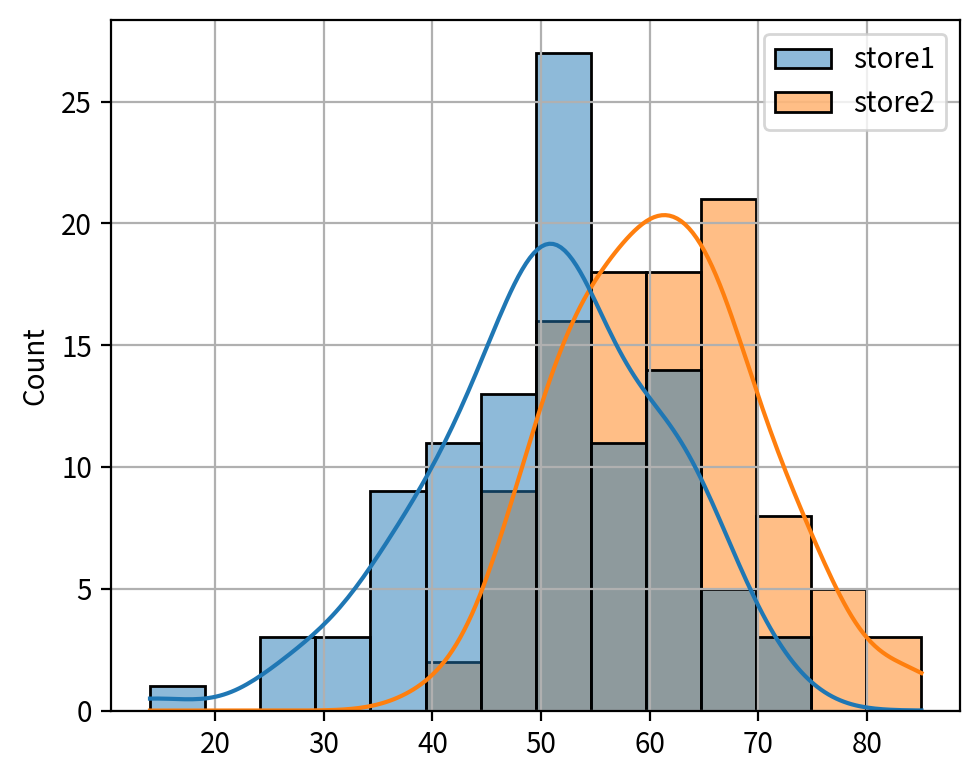

In [5]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

#2) 그래프 그리기 -> seaborn 사용
sb.histplot(data=origin,kde=True)

#3) 그래프 꾸미기
ax.grid(True)


plt.tight_layout()
#plt.savefig("myplot.png", dpi=my_dpi)
plt.show() # 그래프 화면 출력
plt.close()

In [6]:
s, p = shapiro(origin['store1'])
"statistic: {0:.3f}, p-value: {1:.3f}, 정규성 충족 여부: {2}".format(s,p, p > 0.05)

'statistic: 0.979, p-value: 0.109, 정규성 충족 여부: True'

In [7]:
s, p = shapiro(origin['store2'])
"statistic: {0:.3f}, p-value: {1:.3f}, 정규성 충족 여부: {2}".format(s,p, p > 0.05)

'statistic: 0.991, p-value: 0.731, 정규성 충족 여부: True'

In [8]:
s = skew(origin['store1'])
print("왜도: %0.3f" % s)
print("왜도의 절대값: %0.3f" % abs(s))

왜도: -0.506
왜도의 절대값: 0.506


In [9]:
k = kurtosis(origin['store1'])
print("첨도: %0.3f" % k)
print("첨도의 절대값: %0.3f" % abs(k))

첨도: 0.422
첨도의 절대값: 0.422


In [10]:
s = skew(origin['store2'])
k = kurtosis(origin['store2'])
print("왜도의 절대값: %0.3f, 첨도의 절대값: %0.3f" % (abs(s), abs(k)))

왜도의 절대값: 0.251, 첨도의 절대값: 0.178


In [12]:
s, p = normaltest(origin['store1'])
"statistic: {0:.3f}, p-value: {1:.3f}, 정규성 충족 여부: {2}".format(s,p, p > 0.05)

'statistic: 5.651, p-value: 0.059, 정규성 충족 여부: True'

In [13]:
s, p = normaltest(origin['store2'])
"statistic: {0:.3f}, p-value: {1:.3f}, 정규성 충족 여부: {2}".format(s,
p, p > 0.05)

'statistic: 1.174, p-value: 0.556, 정규성 충족 여부: True'

In [16]:
fmt = "[{0}] statistic: {1:.3f}, p-value: {2:.3f}, 정규성 충족 여부: {3}"

for c in origin.columns:
    s, p = normaltest(origin[c])
    print(fmt.format(c, s, p, p == 0.05))

[store1] statistic: 5.651, p-value: 0.059, 정규성 충족 여부: False
[store2] statistic: 1.174, p-value: 0.556, 정규성 충족 여부: False


In [18]:
# 파라미터 수의 제한이 없다.
s, p = bartlett(origin['store1'], origin['store2'])
print("Bartlett 검정: statistic: {0:.3f}, p-value: {1:.3f}, 등분산성 충족여부: {2}".format(s, p, p > 0.05))

Bartlett 검정: statistic: 3.143, p-value: 0.076, 등분산성 충족여부: True


In [19]:
# 파라미터 수의 제한이 없다.
s, p = levene(origin['store1'], origin['store2'])
print("Levene 검정: statistic: {0:.3f}, p-value: {1:.3f}, 등분산성 충족 여부: {2}".format(s, p, p > 0.05))

Levene 검정: statistic: 1.360, p-value: 0.245, 등분산성 충족 여부: True


In [21]:
normal_dist = True # 정규성 만족 여부
data = origin.copy() # 원본 데이터 복사
fields = list(map(lambda x: data[x], data.columns))
if normal_dist:
    n = "Bartlett"
    s, p = bartlett(*fields)
else:
    n = "Levene"
    s, p = levene(*fields)

print("{0} 검정: statistic: {1:.3f}, p-value: {2:.3f}, 정규성 충족 여부:{3}".format(n, s, p, p > 0.05))

Bartlett 검정: statistic: 3.143, p-value: 0.076, 정규성 충족 여부:True


In [29]:
data = melt(origin, var_name="store", value_name="value")
data

,store,value
0,store1,34
1,store1,63
2,store1,57
3,store1,50
4,store1,37
...,...,...
195,store2,69
196,store2,51
197,store2,65
198,store2,59


In [30]:
xname = 'store'
yname = 'value'

u1 = data[xname].unique()
equal_var_fields = []
normal_dist = True
report = []

for i in u1:
    filtered_data = data[data[xname] == i][yname]
    equal_var_fields.append(filtered_data)
    s, p = normaltest(filtered_data)

    normalize = p > 0.05
    report.append({
        "field": i,
        "statistic": s,
        "p-value": p,
        "result": normalize
    })
    normal_dist = normal_dist and normalize
if normal_dist:
    n = "Bartlett"
    s, p = bartlett(*equal_var_fields)
else:
    n = "Levene"
    s, p = levene(*equal_var_fields)
    
report.append({
    "field": n,
    "statistic": s,
    "p-value": p,
    "result": p > 0.05
})
report_df = DataFrame(report).set_index('field')
report_df

,statistic,p-value,result
field,,,
store1,5.651229,0.059272,True
store2,1.173772,0.556056,True
Bartlett,3.143307,0.076239,True
